# Exploración de los Datos (EDA)

## Imports Básicos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de Base de Datos y Análisis preliminar

In [3]:
# Read the CSV file
churn_data = pd.read_csv("../data/telco_churn.csv", sep=",")

# View the first 5 rows
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Get information about the dataset
churn_data.info()

# Get summary statistics
churn_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
# Check for missing values
print(f"Missing values:\n{churn_data.isnull().sum()}")

# Dimensions of the dataset (rows, columns)
print(f"Dataset shape: {churn_data.shape}")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Dataset shape: (7043, 21)


- ¿Qué representan cada Fila y Columna?
    - Las filas representan a cada una de las personas asociadas, mientras que las columnas representan las características y propiedas de cada individuo, por lo que de esta manera se puede realizar un mejor seguimiento a cada uno, con el fin de poder realizar futuras predicciones a nivel global.
- ¿Qué tipo de problema es este?
    - Este es un problema de **clasificación binaria**, porque la variable objetivo `churn` solo tiene dos valores posibles: `Yes` o `No`. Eso lo distingue de otros tipos de problemas como regresión (predecir un número continuo) o clasificación multiclase (predecir entre 3 o más categorías).
- ¿Cuál es la variable objetivo?
    - La variable objetivo es el "Churn", puesto que primero es el nombre de este proyecto y buscamos su predicción, pero más a fondo, es el valor que nos indica posibles fugas y/o retornos de compra de cada usuario.

- Dato importante a tener en cuenta para la limpieza, es un error de "lectura" sobre la columna `TotalCharges`, la cual de momento es identificada como `str` cuando debería ser numérica, al igual que las demás variables relacionadas a montos de pago. La razón más probable es que hay espacios en blanco estilo `" "` en aquella columna, por lo que pandas no logra reconocerlos como nulos, y por ende trata todo como texto. 

## Estadística Básica e inicial

Hay que buscar las variables que podrían explicar por qué alguien se va.
Por lo que, mirando el dataset, tenemos que las posibles variables numéricas reales son solo tres:

1. `tenure`: Meses como cliente
2. `MonthlyCarges`: Cobro mensual
3. `TotalCharges`: Cobro total

Y por ende serán el foco inicial del análisis del proyecto. Teniendo así como pregunta guía de todo el análisis: ¿Se comportan estas variables de forma diferente entrew clientes que hicieron Churn y los que no?

### Tenure

In [28]:
churn_data.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Los clientes que no hacen Churn tienen una media de 37.5 meses y una mediana de 38 meses, mientras que los que sí hacen Churn tienen una media de 17.9 meses y una mediana de apenas 10 meses.

Esa diferencia es enorme y nos dice algo muy claro: los clientes que se van, se van rápido. La mediana de 10 meses en el grupo Churn significa que la mitad de los clientes que abandonan lo hacen antes de cumplir su primer año. Esto tiene sentido de negocio: un cliente que lleva 5 años contigo probablemente ya está comprometido con la empresa, mientras que uno que lleva 2 meses todavía está evaluando si vale la pena quedarse.

La desviación estándar también es reveladora. En el grupo No Churn es de 24.1, y en el grupo Churn es de 19.5. Ambas son altas en relación a sus medias, lo que nos dice que hay bastante variabilidad, pero el grupo Churn tiene una distribución más concentrada en valores bajos, como confirma el percentil 75% de 29 meses, es decir, el 75% de los clientes que se van llevan menos de 29 meses.

Text(0.5, 1.0, 'Tenure by Churn')

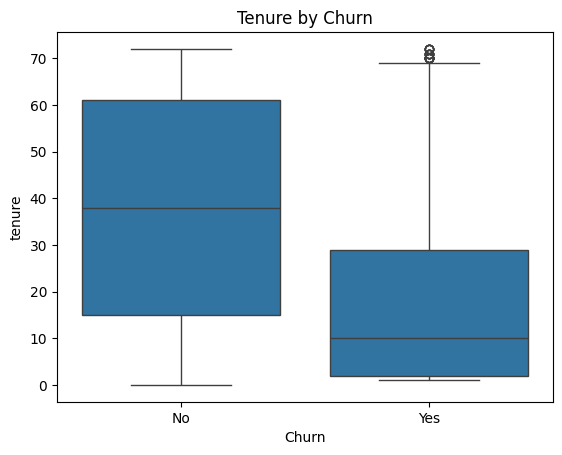

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=churn_data)
plt.title("Tenure by Churn")


El gráfico de tenure es probablemente el más elocuente de los dos. La caja del grupo No Churn es grande y está ubicada en valores altos, con una mediana cerca de los 38 meses y el 75% de los clientes superando los 15 meses. La caja del grupo Churn en cambio es más pequeña, está completamente desplazada hacia abajo, y su mediana ronda los 10 meses. Visualmente puedes ver que casi no hay superposición entre ambas cajas, lo cual es una señal muy fuerte: tenure es una variable muy poderosa para predecir el Churn.

Nota además los pequeños círculos en la parte superior del grupo Churn. Esos son outliers, clientes que llevaban mucho tiempo con la empresa y aun así se fueron. Son casos interesantes porque van contra la tendencia general, y en un análisis más profundo valdría la pena preguntarse qué tienen en común esos clientes.

### MonthlyCharges

In [ ]:
churn_data.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Aquí el patrón es el inverso. Los clientes que hacen Churn pagan en promedio $74.4 al mes, versus $61.2 de los que se quedan. La mediana del grupo Churn es $79.6, bastante más alta que los $64.4 del grupo No Churn.

Esto también tiene sentido: los clientes con planes más caros probablemente tienen mayores expectativas de calidad del servicio, y si no se sienten satisfechos, tienen más incentivo para buscar alternativas más baratas. Además, el percentil 25% del grupo Churn es $56.1, lo que significa que incluso el cuarto inferior de los clientes que se van ya paga más que la mediana del grupo que se queda.

Text(0.5, 1.0, 'Monthly Charges by Churn')

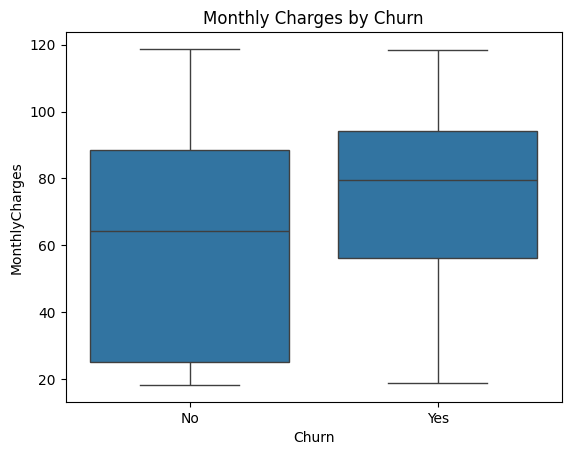

In [31]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=churn_data)
plt.title("Monthly Charges by Churn")

El gráfico muestra una diferencia más sutil pero igual de relevante. Las cajas se superponen bastante más que en el caso de tenure, pero el grupo Churn está consistentemente más arriba. La mediana del grupo Churn ronda los $79, mientras que la del grupo No Churn está cerca de los $64. También notas que la caja del grupo Churn es más compacta, lo que indica que los clientes que se van tienden a pagar montos más similares entre sí, concentrados en la franja alta de precios.

### Conclusión Preliminar

Los clientes más propensos a hacer Churn son aquellos que llevan poco tiempo en la empresa y pagan montos mensuales relativamente altos. Eso tiene lógica: son clientes nuevos, que todavía no han desarrollado lealtad, y que además sienten el peso de una cuenta cara. Si el servicio no cumple sus expectativas inmediatamente, tienen toda la razón para irse.

## Análisis Variables Categóricas

Las variables categóricas más relevantes para el Churn en este dataset son tres:

`Contract` — el tipo de contrato del cliente (mensual, anual, dos años)
`InternetService` — el tipo de internet contratado
`PaymentMethod` — cómo paga el cliente

La pregunta que guía el análisis es la misma de antes, pero aplicada a categorías:

> **¿En qué tipo de contrato, servicio o método de pago se concentra más el Churn?**

Para responderla se necesita calcular la **tasa de Churn por categoría**, es decir, qué porcentaje de clientes dentro de cada grupo hizo Churn. 

Para visualizarlo, el gráfico ha emplear aquí no es un boxplot sino un **gráfico de barras**. 

### Contract

In [44]:
contractBinarieChurnProportion = churn_data.groupby("Contract")["BinarieChurn"].mean()
contractBinarieChurnProportion

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: BinarieChurn, dtype: float64

Realizamos una gráfica de barras para visualizar la distribución de los casos de Churn y no, logrando evidenciar de manera más clara las proporciones de las categorías y los casos.

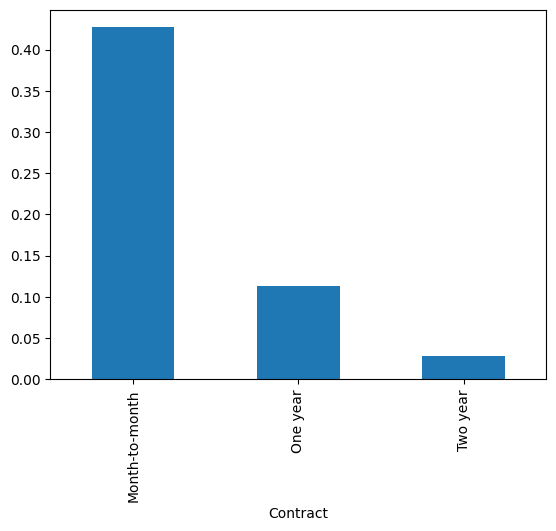

In [56]:
contractBinarieChurnProportion.plot(kind="bar", stacked=False)
plt.show()

El tipo de contrato es uno de los predictores más fuertes de Churn en este dataset. El 43% de los clientes con contrato mes a mes abandona el servicio, una tasa que cae drásticamente a menos del 12% en contratos anuales y bianuales. Esto sugiere que el compromiso contractual actúa como un ancla de retención: a mayor plazo comprometido, menor disposición a irse. Para el negocio, esto implica que una estrategia de conversión de contratos mensuales a anuales, posiblemente mediante descuentos o beneficios adicionales, podría tener un impacto directo y medible en la tasa de Churn.

### InternetService

In [47]:
internetServiceChurnPr = churn_data.groupby("InternetService")["BinarieChurn"].mean()
internetServiceChurnPr

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: BinarieChurn, dtype: float64

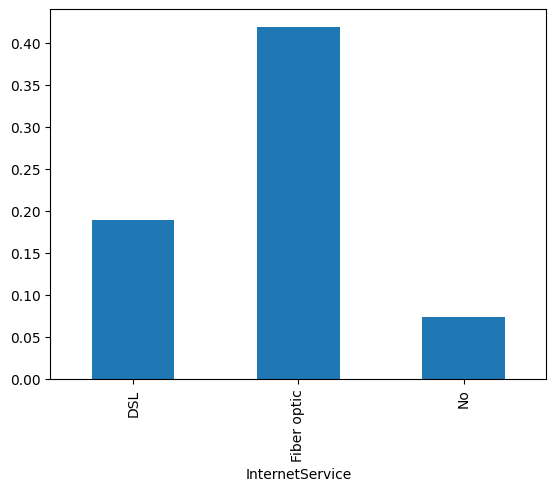

In [55]:
internetServiceChurnPr.plot(kind="bar", stacked=False)
plt.show()

Los clientes con fibra óptica presentan la tasa de Churn más alta del dataset, con un 42% de abandono, lo cual es llamativo considerando que la fibra óptica es generalmente el servicio premium más caro. Este patrón, combinado con lo observado en MonthlyCharges, refuerza una hipótesis importante: los clientes que pagan más no necesariamente están más satisfechos. Es posible que la empresa tenga problemas de calidad o soporte específicamente en ese segmento, o que los competidores estén ofreciendo fibra óptica a menor precio. Este grupo merece atención prioritaria tanto en retención como en investigación de causas.

### PaymentMethod

In [50]:
paymentMethodChurnPr = churn_data.groupby("PaymentMethod")["BinarieChurn"].mean()
paymentMethodChurnPr

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: BinarieChurn, dtype: float64

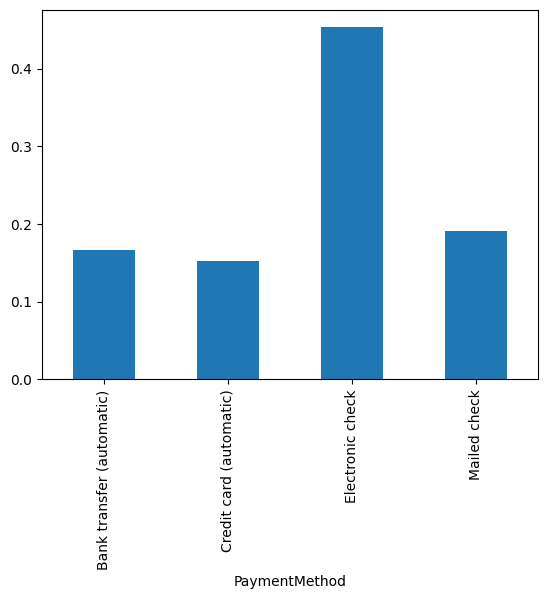

In [54]:
paymentMethodChurnPr.plot(kind="bar", stacked=False)
plt.show()

El método de pago con mayor tasa de Churn es el cheque electrónico, con un 45% de abandono, más del doble que los métodos de pago automático como transferencia bancaria o tarjeta de crédito, que rondan el 15-17%. Esto no es casual: los métodos de pago automático requieren que el cliente ingrese datos bancarios de forma activa, lo que implica un mayor nivel de compromiso y fricción para cancelar. En contraste, el cheque electrónico es el método más fácil de dejar de usar. La recomendación de negocio aquí es clara: incentivar activamente la migración a métodos de pago automático, ya que reduce el Churn de forma indirecta al aumentar la inercia de permanencia.